# 📈 X/Twitter strategy audit: MACD + RSI mean reversion on SMH

## 🧭 tl;dr

An X post from QuantifiedStrategies highlighted a MACD + RSI strategy on the semiconductor ETF SMH and referenced a **73% win rate**. The linked article describes a third mean-reversion filter but does not expose every implementation detail in the public post. This notebook therefore tests a clearly labeled approximation rather than pretending to reproduce proprietary code.

> Educational research only. Not financial advice. A high win rate can coexist with a poor payoff ratio, large drawdown, or fragile costs.

<div style="border-left: 5px solid #7C3AED; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F5F3FF; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>Read the public claim, inspect the approximation, then compare full-sample and untouched-test results. The cost table is essential because this is a short-horizon strategy.</div>


## 📚 Source and research question

The X post points readers to QuantifiedStrategies’ public article. The article reports, for its SMH backtest, 235 trades, 73% win rate, approximately 0.88% average gain per trade, 8% CAGR, and a −46% maximum drawdown after a 0.03% commission/slippage assumption.

Sources: [X post](https://x.com/QuantifiedStrat/status/2013527816940462540) and [public MACD + RSI article](https://www.quantifiedstrategies.com/?p=133255).

**Research question:** does a transparent MACD/RSI/mean-reversion implementation show similar behavior after a one-bar delay, a chronological test split, and a range of transaction costs?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_smh():
    try:
        data = load_price_data("SMH", "2001-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily SMH OHLCV"
    except Exception as exc:
        data = make_demo_ohlcv(periods=6_200, seed=505, start="2001-01-01")
        source = f"deterministic demo OHLCV fallback ({type(exc).__name__})"
    return data, source


ohlcv, data_source = load_smh()
print(f"Data source: {data_source}")
print(f"Observations: {len(ohlcv):,} | {ohlcv.index.min().date()} to {ohlcv.index.max().date()}")
display(ohlcv.head())


Data source: Yahoo Finance adjusted daily SMH OHLCV
Observations: 6,287 | 2001-01-02 to 2025-12-31


,open,high,low,close,volume
Date,,,,,
2001-01-02,21.123044,21.386285,20.065829,20.507397,4358800.0
2001-01-03,20.507394,23.963506,19.615769,23.882835,4023200.0
2001-01-04,23.776695,24.328653,22.863839,23.144064,3143200.0
2001-01-05,22.931773,23.224737,21.560367,21.759922,3702400.0
2001-01-08,21.441487,22.188754,20.808856,22.074118,1833800.0


## 📜 Transparent approximation of the public description

The public post does not provide a complete, line-by-line rule set. To create an auditable test, we use standard indicator definitions and expose all choices:

- MACD = 12-day EMA − 26-day EMA; signal line = 9-day EMA of MACD.
- RSI = 14-day Wilder-style RSI.
- **Entry:** MACD is above its signal line, RSI is below 50, and close is below the 5-day moving average. The last condition is the mean-reversion filter.
- **Exit:** close returns above the 5-day moving average, or MACD falls below its signal line.
- **Execution:** signal at today’s close is held for the next session; 10 bps is the project default cost.

The RSI threshold, mean-reversion window, and exit details are approximation parameters—not facts recovered from the X post. That distinction is the main research caveat.


In [3]:

def macd_rsi_signal(close, rsi_threshold=50.0, mean_reversion_window=5):
    close = pd.Series(close, dtype=float)
    fast = close.ewm(span=12, adjust=False, min_periods=12).mean()
    slow = close.ewm(span=26, adjust=False, min_periods=26).mean()
    macd_line = fast - slow
    signal_line = macd_line.ewm(span=9, adjust=False, min_periods=9).mean()
    change = close.diff()
    gain = change.clip(lower=0.0).ewm(alpha=1 / 14, adjust=False, min_periods=14).mean()
    loss = (-change.clip(upper=0.0)).ewm(alpha=1 / 14, adjust=False, min_periods=14).mean()
    rsi = 100.0 - 100.0 / (1.0 + gain / loss.replace(0.0, np.nan))
    mean = close.rolling(mean_reversion_window, min_periods=mean_reversion_window).mean()

    target = pd.Series(0.0, index=close.index, name="target_position")
    state = 0.0
    for timestamp in close.index:
        entry = macd_line.loc[timestamp] > signal_line.loc[timestamp] and rsi.loc[timestamp] < rsi_threshold and close.loc[timestamp] < mean.loc[timestamp]
        exit_ = close.loc[timestamp] > mean.loc[timestamp] or macd_line.loc[timestamp] < signal_line.loc[timestamp]
        if state == 0.0 and entry:
            state = 1.0
        elif state == 1.0 and exit_:
            state = 0.0
        target.loc[timestamp] = state
    diagnostics = pd.DataFrame({"close": close, "macd": macd_line, "signal": signal_line, "rsi": rsi, "mean": mean, "target_position": target})
    return target, diagnostics


target, diagnostics = macd_rsi_signal(ohlcv["close"])
result = run_backtest(ohlcv["close"], target, transaction_cost_bps=10.0, benchmark_returns=ohlcv["close"].pct_change().fillna(0.0))
benchmark = run_backtest(ohlcv["close"], pd.Series(1.0, index=ohlcv.index), transaction_cost_bps=10.0)
splits = split_time_series(ohlcv[["close"]])
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results and claim audit

The exact public claim is included as context, not as a target to optimize toward. The strategy is evaluated with the project’s daily portfolio Sharpe and the untouched test period.


In [4]:

rows = []
for name, backtest in [("MACD + RSI approximation", result), ("SMH buy & hold", benchmark)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(backtest, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
summary = pd.DataFrame(rows).set_index(["strategy", "period"])
display(summary[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "win_rate", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "win_rate": "{:.2%}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))
print("Public claim: 73% win rate, 8% CAGR, -46% max drawdown, 235 trades.")


Public claim: 73% win rate, 8% CAGR, -46% max drawdown, 235 trades.


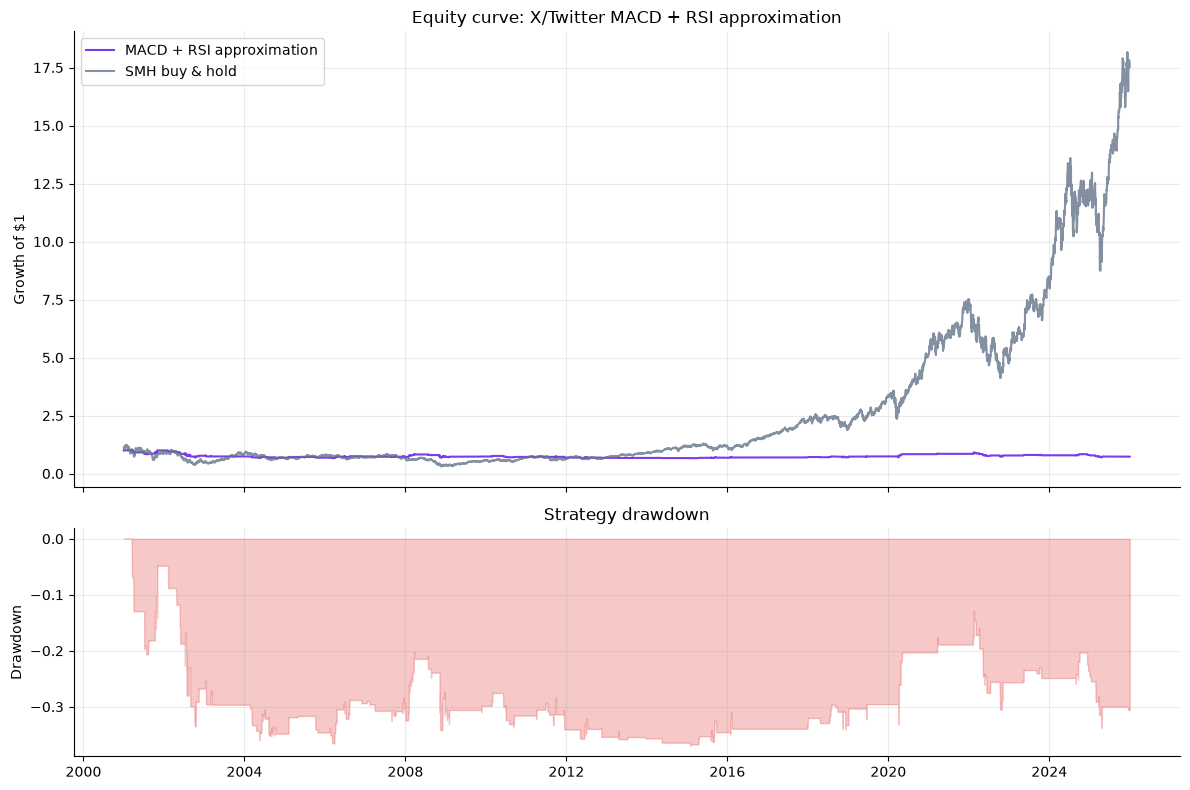

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(result.frame.index, result.equity / result.equity.iloc[0], label="MACD + RSI approximation", color="#7C3AED")
axes[0].plot(benchmark.frame.index, benchmark.equity / benchmark.equity.iloc[0], label="SMH buy & hold", color="#64748B", alpha=0.8)
axes[0].set_title("Equity curve: X/Twitter MACD + RSI approximation")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(result.frame.index, result.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Strategy drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧪 Robustness and costs

Because the public rules are incomplete, parameter sensitivity is especially important. The grid is ranked on validation only; the original approximation is still the one reported on the untouched test period.


In [6]:

grid_rows = []
for rsi_threshold, mean_window in itertools.product([30.0, 40.0, 50.0, 60.0], [3, 5, 10]):
    candidate, _ = macd_rsi_signal(ohlcv["close"], rsi_threshold, mean_window)
    candidate_result = run_backtest(ohlcv["close"], candidate, transaction_cost_bps=10.0, benchmark_returns=ohlcv["close"].pct_change().fillna(0.0))
    validation = metrics_for_period(candidate_result, periods["validation"])
    test = metrics_for_period(candidate_result, periods["test"])
    grid_rows.append({"rsi_threshold": rsi_threshold, "mean_window": mean_window, "validation_sharpe": validation["sharpe_ratio"], "validation_return": validation["annualized_return"], "test_sharpe": test["sharpe_ratio"], "test_return": test["annualized_return"], "test_drawdown": test["max_drawdown"]})
sensitivity = pd.DataFrame(grid_rows).sort_values("validation_sharpe", ascending=False)
display(sensitivity.style.format({"validation_sharpe": "{:.2f}", "validation_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_return": "{:.2%}", "test_drawdown": "{:.2%}"}))


,rsi_threshold,mean_window,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
11,60.000000,10,1.01,8.21%,-0.33,-3.57%,-26.44%
9,60.000000,3,0.92,10.29%,0.00,-0.89%,-31.75%
10,60.000000,5,0.89,9.10%,0.14,0.92%,-29.44%
8,50.000000,10,0.77,5.39%,-0.71,-5.96%,-32.32%
5,40.000000,10,0.70,2.19%,-0.25,-0.81%,-9.16%
4,40.000000,5,0.65,2.09%,-0.25,-0.81%,-9.16%
6,50.000000,3,0.59,4.61%,-0.83,-6.99%,-33.51%
7,50.000000,5,0.54,4.03%,-0.32,-2.73%,-24.01%
3,40.000000,3,0.51,1.45%,-0.58,-1.52%,-9.16%
0,30.000000,3,0.00,0.00%,0.00,0.00%,0.00%


In [7]:

cost_rows = []
for cost_bps in [0, 3, 10, 25, 50]:
    cost_result = run_backtest(ohlcv["close"], target, transaction_cost_bps=cost_bps, benchmark_returns=ohlcv["close"].pct_change().fillna(0.0))
    metrics = metrics_for_period(cost_result, periods["test"])
    cost_rows.append({"transaction_cost_bps": cost_bps, "test_return": metrics["annualized_return"], "test_sharpe": metrics["sharpe_ratio"], "test_drawdown": metrics["max_drawdown"], "test_turnover": metrics["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_drawdown": "{:.2%}", "test_turnover": "{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,-1.51%,-0.16,-19.93%,12.42
1,3,-1.87%,-0.21,-21.18%,12.42
2,10,-2.73%,-0.32,-24.01%,12.42
3,25,-4.53%,-0.55,-29.74%,12.42
4,50,-7.47%,-0.91,-38.37%,12.42


## ⚖️ What went well / what went wrong

### ✅ What went well

- The public post points to a specific market and recognizable indicators, making a transparent approximation possible.
- The combined signal can reduce time in the market compared with buy and hold.
- The notebook exposes the distinction between win rate, Sharpe, drawdown, and turnover.

### ⚠️ What went wrong or remains uncertain

- The public description omits a key filter’s exact definition and parameter values, so this is not an exact replication.
- A 73% win rate does not guarantee positive expectancy; large losses and long drawdowns can dominate.
- Semiconductor ETFs can have strong structural trends, so the benchmark and sample start date matter.
- Short-horizon signals can lose their edge after spread, slippage, and execution delay.

**Bottom line:** the X claim is a useful research prompt, not a verified performance result. The reproducible conclusion is the cost-aware untouched-test table above.
